# Импорты

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
test = pd.read_csv("test.csv")
train = pd.read_csv("train.csv")

In [ ]:
test

,id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty
0,630000,24,other,ba,6.85,65.2,yes,5.2,poor,group study,high,easy
1,630001,18,male,diploma,6.61,45.0,no,9.3,poor,coaching,low,easy
2,630002,24,female,b.tech,6.60,98.5,yes,6.2,good,group study,medium,moderate
3,630003,24,male,diploma,3.03,66.3,yes,5.7,average,mixed,medium,moderate
4,630004,20,female,b.tech,2.03,42.4,yes,9.2,average,coaching,low,moderate
...,...,...,...,...,...,...,...,...,...,...,...,...
269995,899995,21,other,b.com,2.55,82.3,yes,8.4,average,mixed,medium,hard
269996,899996,17,female,b.com,0.49,46.4,yes,8.8,good,mixed,low,easy
269997,899997,22,male,bba,6.62,74.7,yes,5.5,good,coaching,high,easy
269998,899998,22,other,ba,4.08,51.8,yes,8.7,poor,online videos,high,moderate


In [ ]:
train

,id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,0,21,female,b.sc,7.91,98.8,no,4.9,average,online videos,low,easy,78.300
1,1,18,other,diploma,4.95,94.8,yes,4.7,poor,self-study,medium,moderate,46.700
2,2,20,female,b.sc,4.68,92.6,yes,5.8,poor,coaching,high,moderate,99.000
3,3,19,male,b.sc,2.00,49.5,yes,8.3,average,group study,high,moderate,63.900
4,4,23,male,bca,7.65,86.9,yes,9.6,good,self-study,high,easy,100.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
629995,629995,18,female,b.tech,4.86,70.7,yes,4.1,good,mixed,high,moderate,69.500
629996,629996,21,female,ba,7.08,54.4,yes,4.5,average,mixed,low,moderate,78.900
629997,629997,24,male,bca,0.64,44.2,yes,4.3,poor,online videos,low,moderate,19.599
629998,629998,20,male,b.com,1.54,75.1,yes,8.2,average,group study,high,moderate,59.100


In [ ]:
X_train = train[list(test.columns)].drop(columns='id')
y_train = train['exam_score']
X_test = test.copy().drop(columns='id')

#Очевидно, что дропаем айди

# Предобработка данных

In [ ]:
numeric_features = X_test.select_dtypes(include=['int64', 'float64']).columns.tolist()[:-1]
categorical_features = X_test.select_dtypes(include=['object', 'category']).columns.tolist()

In [ ]:
print(numeric_features)
print(categorical_features)

['age', 'study_hours', 'class_attendance']
['gender', 'course', 'internet_access', 'sleep_quality', 'study_method', 'facility_rating', 'exam_difficulty']


In [ ]:
print(train.isna().sum())
print(test.isna().sum())
print(train.duplicated().sum())
print(test.duplicated().sum())

id                  0
age                 0
gender              0
course              0
study_hours         0
class_attendance    0
internet_access     0
sleep_hours         0
sleep_quality       0
study_method        0
facility_rating     0
exam_difficulty     0
exam_score          0
dtype: int64
id                  0
age                 0
gender              0
course              0
study_hours         0
class_attendance    0
internet_access     0
sleep_hours         0
sleep_quality       0
study_method        0
facility_rating     0
exam_difficulty     0
dtype: int64
0
0


#Нет ни дубликатов, ни нанов

In [ ]:
scaler = StandardScaler()


scaler.fit(X_train[numeric_features])

X_train[numeric_features] = scaler.transform(X_train[numeric_features])
X_test[numeric_features] = scaler.transform(X_test[numeric_features])

print("Пример:", X_train[numeric_features].head(2))

✅ Числовые признаки обработаны
Пример:         age  study_hours  class_attendance
0  0.200943     1.655875          1.538302
1 -1.126352     0.401573          1.308814


In [ ]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

encoder.fit(X_train[categorical_features])

X_train_cat = encoder.transform(X_train[categorical_features])
X_test_cat = encoder.transform(X_test[categorical_features])


print("Сколько новых колонок:", X_train_cat.shape[1])

Сколько новых колонок: 26


In [ ]:
cat_columns = encoder.get_feature_names_out(categorical_features)

X_train_cat_df = pd.DataFrame(X_train_cat, columns=cat_columns, index=X_train.index)
X_test_cat_df = pd.DataFrame(X_test_cat, columns=cat_columns, index=X_test.index)

X_train_final = pd.concat([X_train[numeric_features], X_train_cat_df], axis=1)
X_test_final = pd.concat([X_test[numeric_features], X_test_cat_df], axis=1)

In [ ]:
print(X_test_final)

             age  study_hours  class_attendance  gender_female  gender_male  \
0       1.528239     1.206699         -0.389399            0.0          0.0   
1      -1.126352     1.104999         -1.548315            0.0          1.0   
2       1.528239     1.100761          1.521091            1.0          0.0   
3       1.528239    -0.412029         -0.326290            0.0          1.0   
4      -0.241488    -0.835779         -1.697482            1.0          0.0   
...          ...          ...               ...            ...          ...   
269995  0.200943    -0.615429          0.591663            0.0          0.0   
269996 -1.568784    -1.488355         -1.467994            1.0          0.0   
269997  0.643375     1.109236          0.155635            0.0          1.0   
269998  0.643375     0.032910         -1.158185            0.0          0.0   
269999 -0.241488     0.787186         -0.704946            1.0          0.0   

        gender_other  course_b.com  course_b.sc  co

In [ ]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)

model.fit(X_train_final, y_train)



✅ Модель обучена!


In [ ]:

predictions = model.predict(X_test_final)

submission = pd.DataFrame({
    'id': test['id'],
    'exam_score': predictions.round(2)
})

submission.to_csv('submission.csv', index=False)

print(submission.head())

✅ Предсказания сохранены!
       id  exam_score
0  630000       68.25
1  630001       66.27
2  630002       82.35
3  630003       58.70
4  630004       43.63


📈 МЕТРИКИ КАЧЕСТВА МОДЕЛИ
R² (Train): 0.9638
  → Объясняет 96.4% дисперсии данных

MSE: 12.97
  → Средняя квадратичная ошибка

RMSE: 3.60
  → Средняя ошибка в тех же единицах, что и оценка

MAE: 2.82
  → Средняя ошибка по модулю

📊 Точность модели: ~94.2%

📋 СТАТИСТИКА ПРЕДСКАЗАНИЙ
Реальные оценки (train):
  Средний: 62.51
  Мин: 19.60, Макс: 100.00
  Стд: 18.92

Предсказанные оценки:
  Средний: 62.50
  Мин: 19.60, Макс: 100.00
  Стд: 17.59


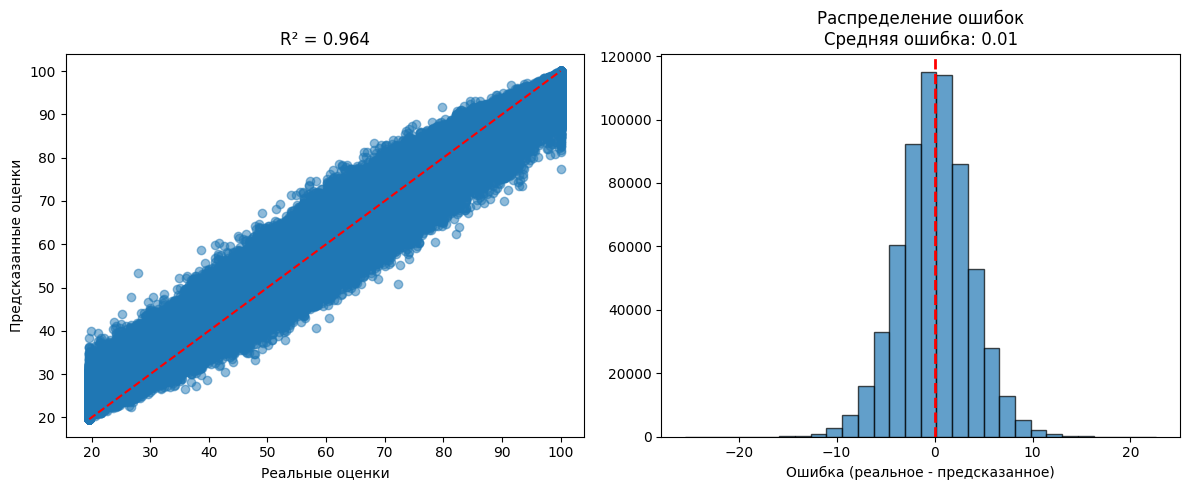

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

y_train_pred = model.predict(X_train_final)



r2 = r2_score(y_train, y_train_pred)
print(f"R² (Train): {r2:.4f}")
print(f"  → Объясняет {r2*100:.1f}% дисперсии данных")


mse = mean_squared_error(y_train, y_train_pred)
print(f"\nMSE: {mse:.2f}")
print(f"  → Средняя квадратичная ошибка")


rmse = np.sqrt(mse)
print(f"\nRMSE: {rmse:.2f}")
print(f"  → Средняя ошибка в тех же единицах, что и оценка")


mae = mean_absolute_error(y_train, y_train_pred)
print(f"\nMAE: {mae:.2f}")
print(f"  → Средняя ошибка по модулю")

mean_score = y_train.mean()
accuracy_percent = (1 - rmse / mean_score) * 100
print(f"\n📊 Точность модели: ~{accuracy_percent:.1f}%")


print("\n" + "=" * 60)
print("📋 СТАТИСТИКА ПРЕДСКАЗАНИЙ")
print("=" * 60)

print(f"Реальные оценки (train):")
print(f"  Средний: {y_train.mean():.2f}")
print(f"  Мин: {y_train.min():.2f}, Макс: {y_train.max():.2f}")
print(f"  Стд: {y_train.std():.2f}")

print(f"\nПредсказанные оценки:")
print(f"  Средний: {y_train_pred.mean():.2f}")
print(f"  Мин: {y_train_pred.min():.2f}, Макс: {y_train_pred.max():.2f}")
print(f"  Стд: {y_train_pred.std():.2f}")


import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# График: реальные vs предсказанные
plt.subplot(1, 2, 1)
plt.scatter(y_train, y_train_pred, alpha=0.5)
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--')
plt.xlabel('Реальные оценки')
plt.ylabel('Предсказанные оценки')
plt.title(f'R² = {r2:.3f}')

# Гистограмма ошибок
plt.subplot(1, 2, 2)
errors = y_train - y_train_pred
plt.hist(errors, bins=30, edgecolor='black', alpha=0.7)
plt.axvline(0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Ошибка (реальное - предсказанное)')
plt.title(f'Распределение ошибок\nСредняя ошибка: {errors.mean():.2f}')

plt.tight_layout()
plt.show()


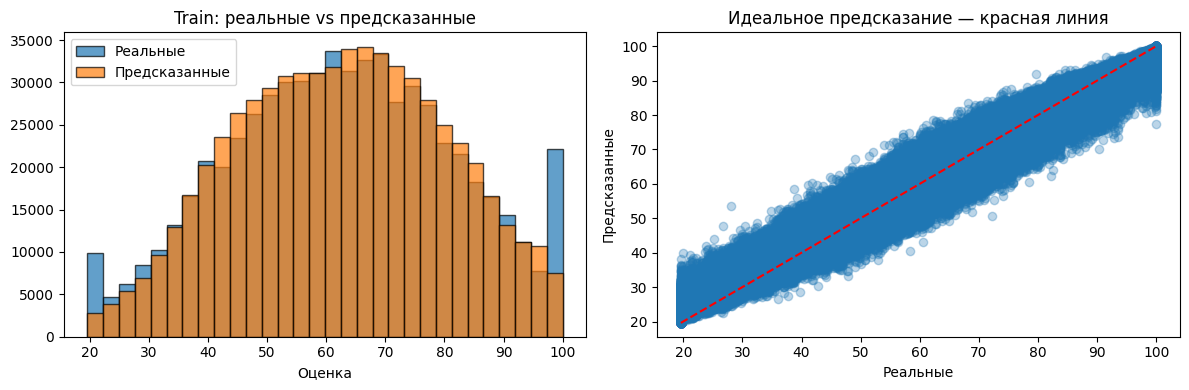


📊 Средняя ошибка по группам оценок:
                 mean       std   count
score_group                            
Low         -2.908884  2.995924   81861
Medium      -0.616814  3.339366  201323
High         0.337291  3.394150  226083
Excellent    2.412096  3.001149  120733


/tmp/ipython-input-633/2728408026.py:37: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(train_with_errors.groupby('score_group')['error'].agg(['mean', 'std', 'count']))


#Достаточно простая задача получилась, модель показывает высокие результаты